
# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Build an Interactive Retail Sales Dashboard

### Scenario

You have just joined the analytics team of **UrbanCart**, a mid-sized retail chain with stores across
three regions. Regional managers currently receive a static monthly PDF report and complain that:

1. They can't drill into *why* a number moved without emailing the analytics team.
2. Comparing stores or products side by side means flipping between many separate PDF pages.
3. Spotting a sudden dip in a specific product/store is slow and easy to miss.

**Your job:** apply the interaction techniques from the lecture — dynamic queries, coordinated views
& brushing, table lens, focus+context drill-down, and single-screen dashboard design — to build an
**interactive exploration tool** that solves these three complaints.

### How this notebook is organized

- A sample dataset is generated for you (Task 0) — don't skip running it.
- Each task states the **real-world usage**: which complaint above it solves, and why the technique
  fits.
- Tasks give you a **scaffold** (imports, helper stubs, expected output) — **you write the core logic**
  marked with `# TODO`. Do not just copy the Demo notebook's code verbatim — the data shape, column
  names and the exact question being asked are different here, so you will need to adapt the pattern,
  not paste it.


> **Grading-relevant tip:** every `# TODO` cell tells you what the final variable/plot must be named
> or show — read it before coding, since later cells depend on it.



## Task 0 — Load the Sample Dataset (provided)

Run the cells below as-is. This generates `sales_df`: 24 months of daily-aggregated sales across
6 stores (3 regions), 10 products (4 categories), including revenue, profit and customer ratings —
enough structure to support every technique you'll build below.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import ipywidgets as widgets
from ipywidgets import interact, HBox, VBox

sns.set_theme(style="whitegrid")
np.random.seed(7)
print("Libraries loaded.")


Libraries loaded.


In [2]:

# --- Sample dataset generator: UrbanCart retail sales (provided, do not need to modify) ---
stores = pd.DataFrame({
    "store_id":   ["S01", "S02", "S03", "S04", "S05", "S06"],
    "store_city": ["Bengaluru", "Mysuru", "Mumbai", "Pune", "Delhi", "Jaipur"],
    "region":     ["South", "South", "West", "West", "North", "North"],
})

products = pd.DataFrame({
    "product":  ["Wireless Earbuds", "Smartwatch", "Laptop Sleeve", "USB-C Hub",
                 "Yoga Mat", "Dumbbell Set", "Running Shoes", "Track Jacket",
                 "Air Fryer", "Blender"],
    "category": ["Electronics", "Electronics", "Electronics", "Electronics",
                 "Fitness", "Fitness", "Apparel", "Apparel",
                 "Home", "Home"],
    "unit_price": [1499, 4999, 899, 1299, 799, 2499, 3499, 1999, 3999, 2299],
})

months = pd.date_range("2023-01-01", periods=24, freq="MS")

rows = []
for _, s in stores.iterrows():
    store_scale = np.random.uniform(0.7, 1.4)          # some stores just sell more
    for _, p in products.iterrows():
        product_scale = np.random.uniform(0.6, 1.6)
        trend = np.random.normal(0.01, 0.01)             # slow month-over-month growth/decline
        for i, m in enumerate(months):
            seasonal = 1 + 0.25 * np.sin(2 * np.pi * (m.month / 12))   # yearly seasonality
            units = max(0, np.random.poisson(15 * store_scale * product_scale * seasonal * (1 + trend) ** i))
            revenue = units * p["unit_price"]
            profit_margin = np.random.uniform(0.12, 0.35)
            profit = revenue * profit_margin
            rating = np.clip(np.random.normal(4.1, 0.4), 1, 5)
            # NOTE: use bracket indexing (p["product"]), not p.product -- pandas Series already has
            # a built-in .product() method, so attribute access on a column literally named "product"
            # silently returns that method instead of your data. This is a common real-world gotcha.
            rows.append((m, s["store_id"], s["store_city"], s["region"], p["product"], p["category"],
                         p["unit_price"], units, revenue, profit, round(rating, 1)))

sales_df = pd.DataFrame(rows, columns=[
    "month", "store_id", "store_city", "region", "product", "category",
    "unit_price", "units_sold", "revenue", "profit", "avg_rating"
])
for _col in ["units_sold", "revenue", "profit"]:
    sales_df[_col] = sales_df[_col].astype(float)  # float, so the anomaly injection below can scale them

# Inject one deliberate "anomaly" for Task 4 (a real dip a manager would want to investigate)
mask = (sales_df.store_id == "S03") & (sales_df["product"] == "Smartwatch") & (sales_df.month == "2024-06-01")
sales_df.loc[mask, ["units_sold", "revenue", "profit"]] = sales_df.loc[mask, ["units_sold", "revenue", "profit"]] * 0.15

print(sales_df.shape)
sales_df.head()


(1440, 11)


,month,store_id,store_city,region,product,category,unit_price,units_sold,revenue,profit,avg_rating
0,2023-01-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,17.0,25483.0,4631.305022,3.9
1,2023-02-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,19.0,28481.0,8682.717042,3.8
2,2023-03-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,16.0,23984.0,8014.910391,4.0
3,2023-04-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,31.0,46469.0,11438.468953,4.8
4,2023-05-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,22.0,32978.0,5511.128059,4.2



**Reflection (answer in a sentence or two, in this markdown cell):**
Before writing any code, look at the columns above. Which columns would you use as *filters* for
dynamic querying, and which would you use to *link* views together for brushing? Write your answer
here.

_Your answer:_

For dynamic-query filters I'd use the numeric columns — `unit_price`, `units_sold`, `revenue`, `profit`, `avg_rating`, and `month` (as a date range) — since sliders only make sense on continuous ranges. For linking views via brushing I'd use the categorical/key columns — `store_id`, `region`, `product`, and `category` — because selecting one of these identifies the same records across every other chart.



## Task 1 — Static vs. Interactive: Which Report Actually Answers the Manager's Question?

**Real-world usage:** Complaint #1 ("flipping through PDF pages"). A regional manager asks:
*"Show me total revenue by product, and let me check exactly how much any bar is worth without
squinting at a printed axis."*

**Why this technique:** A static bar chart is fine for the *headline* number, but it can't answer a
precise follow-up question live — that needs a hover-enabled interactive chart (Slide 4-8).

### Your task
1. Build a **static** `matplotlib`/`seaborn` bar chart of total revenue per `product`, sorted
   descending.
2. Build the **same** chart as an **interactive** `plotly` bar chart where hovering shows the exact
   revenue figure and the category of that product.
3. In the markdown cell below, state in 1-2 sentences: for *this specific* manager request, which
   version wins, and why (tie your answer to target-audience / data-story / ROI from the slide).


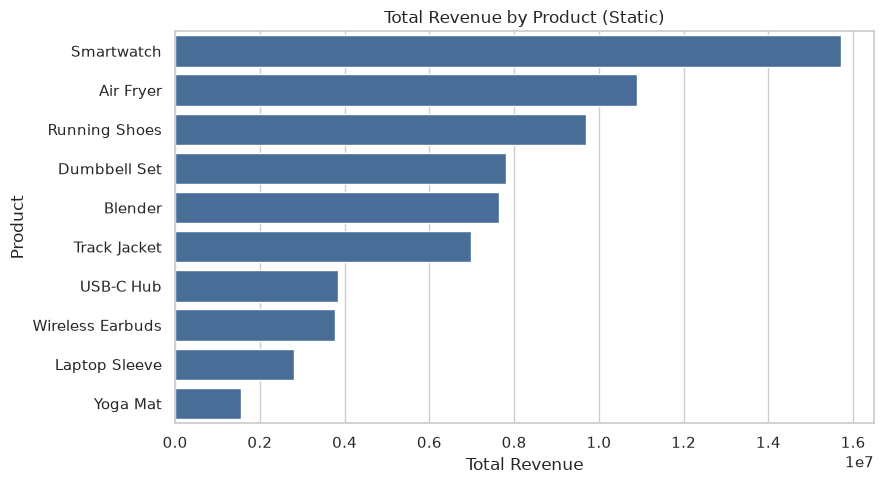

In [3]:

# --- 1a. STATIC chart ---
revenue_by_product = sales_df.groupby("product")["revenue"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=revenue_by_product.values, y=revenue_by_product.index, ax=ax, color="#3b6ea5")
ax.set_xlabel("Total Revenue")
ax.set_ylabel("Product")
ax.set_title("Total Revenue by Product (Static)")
plt.tight_layout()
plt.show()


In [4]:

# --- 1b. INTERACTIVE chart ---
revenue_by_product_cat = sales_df.groupby(["product", "category"], as_index=False)["revenue"].sum()
revenue_by_product_cat = revenue_by_product_cat.sort_values("revenue", ascending=False)

fig_interactive = px.bar(
    revenue_by_product_cat,
    x="product",
    y="revenue",
    color="category",
    hover_data=["category", "revenue"],
    title="Total Revenue by Product (Interactive)",
)
fig_interactive.show()



**Your 1-2 sentence answer:**

_Type here._

The interactive Plotly version wins for this request: the manager explicitly wants the *exact* revenue figure for any bar, and hover gives that on demand while the static chart forces someone to squint at the axis or, worse, email the analytics team back — which is exactly the ROI problem the static-PDF workflow already has. The static chart is still fine as a quick headline visual for a slide, but it can't answer a live follow-up question the way the interactive one can.



## Task 2 — Dynamic Queries: Let Managers Filter Without Asking You

**Real-world usage:** Regional managers want to self-serve answer questions like *"which
products, in what price range, sold above X units last month?"* without emailing the analytics team
every time (Complaint #1 again, but for filtering rather than just reading).

**Why this technique:** Dynamic queries (double-ended range sliders) let the pattern emerge from the
noise live, with the response updating in real time (Slide 23).

### Your task
Build **two** linked `ipywidgets` range sliders:
- `price_slider` — filters on `unit_price`
- `units_slider` — filters on `units_sold`

Write a function `dynamic_filter(price_range, units_range)` that:
1. Filters `sales_df` to rows where `unit_price` is inside `price_range` **and** `units_sold` is
   inside `units_range`.
2. Prints how many rows match out of the total.
3. Shows a scatter plot of `unit_price` vs `units_sold`, with matching rows highlighted in a
   distinct color against all other rows in gray (same pattern as the Demo notebook's dynamic query
   cell — but you must build the filter condition and the plot yourself for these two columns).

Wire it up with `interact()`.


1440 / 1440 rows match


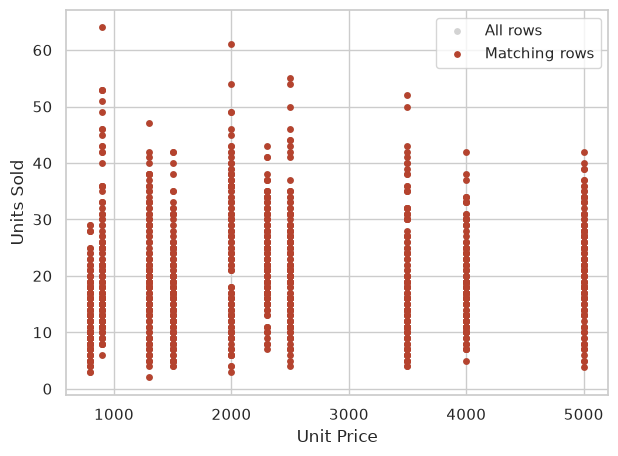

interactive(children=(FloatRangeSlider(value=(799.0, 4999.0), description='Price', max=4999.0, min=799.0, step…

<function __main__.dynamic_filter(price_range, units_range)>

In [5]:

price_slider = widgets.FloatRangeSlider(
    value=[sales_df.unit_price.min(), sales_df.unit_price.max()],
    min=sales_df.unit_price.min(),
    max=sales_df.unit_price.max(),
    step=50,
    description="Price",
)

units_slider = widgets.FloatRangeSlider(
    value=[sales_df.units_sold.min(), sales_df.units_sold.max()],
    min=sales_df.units_sold.min(),
    max=sales_df.units_sold.max(),
    step=1,
    description="Units",
)

def dynamic_filter(price_range, units_range):
    mask = (
        (sales_df.unit_price >= price_range[0]) & (sales_df.unit_price <= price_range[1]) &
        (sales_df.units_sold >= units_range[0]) & (sales_df.units_sold <= units_range[1])
    )
    filtered = sales_df[mask]

    print(f"{len(filtered)} / {len(sales_df)} rows match")

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(sales_df.unit_price, sales_df.units_sold, color="lightgray", s=15, label="All rows")
    ax.scatter(filtered.unit_price, filtered.units_sold, color="#b5432e", s=15, label="Matching rows")
    ax.set_xlabel("Unit Price")
    ax.set_ylabel("Units Sold")
    ax.legend()
    plt.show()

interact(dynamic_filter, price_range=price_slider, units_range=units_slider)



**Reflection:** The slide notes dynamic queries work well "up to ~100,000 points with five or fewer
sliders." `sales_df` has far fewer rows. If UrbanCart grew to 500 stores and this dataset became 50x
larger, would two sliders still be enough, or would you need a different technique from the lecture?
Name one.

_Your answer:_

Right now `sales_df` is only 1,440 rows, and 50x growth would put it around 72,000 rows — still technically under the ~100,000-point guideline, but the scatter plot would already be badly overplotted with that many points rendered as gray/red dots. Two sliders alone would still filter correctly, but visually the pattern would get lost in the clutter, so I'd add a categorical dynamic query (e.g. a `region` or `store_id` dropdown/checkbox group) to narrow the point cloud before the sliders act on it, or move to a table lens / aggregated view instead of a raw scatterplot.



## Task 3 — Coordinated Views & Cross-View Brushing: Compare Stores Without Flipping Pages

**Real-world usage:** Complaint #2 — "comparing stores means flipping between many PDF pages."
A manager wants to click one store in an overview chart and instantly see that store's category
breakdown and its monthly trend, without losing sight of how it compares to the others.

**Why this technique:** Coordinated multiple views + brushing (Slide 24) — selecting a subset in one
view highlights the same records everywhere else, replacing the working-memory cost of flipping pages.

### Your task
Build **three linked views** for a store the user selects from a dropdown:
1. **Overview bar chart** — total revenue per store (all 6 stores), with the selected store's bar in
   a distinct color and every other store's bar in gray (this is the "muted unselected categories"
   trick from the slide).
2. **Category breakdown** — a pie or bar chart of revenue by `category`, filtered to the selected
   store only.
3. **Monthly trend line** — revenue by `month`, filtered to the selected store only.

Wrap all three in one function driven by a single `ipywidgets.Dropdown` of `store_id` values, and lay
the three charts out together (e.g. with `plt.subplots` for 1+2+3, or separate `display()` calls).


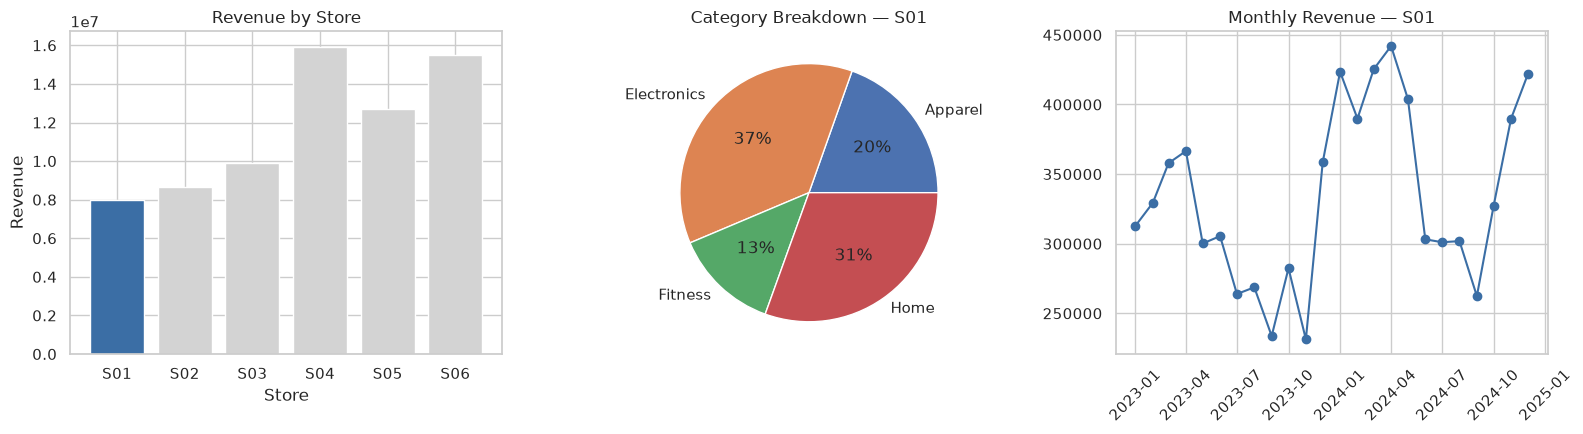

interactive(children=(Dropdown(description='selected_store', options=('S01', 'S02', 'S03', 'S04', 'S05', 'S06'…

<function __main__.store_coordinated_view(selected_store)>

In [6]:

store_overview = sales_df.groupby("store_id").revenue.sum().reset_index()

def store_coordinated_view(selected_store):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    # TODO 1: bar chart of store_overview, selected store highlighted, others muted gray
    colors = ["#3b6ea5" if s == selected_store else "lightgray" for s in store_overview.store_id]
    axes[0].bar(store_overview.store_id, store_overview.revenue, color=colors)
    axes[0].set_title("Revenue by Store")
    axes[0].set_xlabel("Store")
    axes[0].set_ylabel("Revenue")

    # TODO 2: category breakdown pie/bar for selected_store only
    store_df = sales_df[sales_df.store_id == selected_store]
    cat_revenue = store_df.groupby("category").revenue.sum()
    axes[1].pie(cat_revenue.values, labels=cat_revenue.index, autopct="%1.0f%%")
    axes[1].set_title(f"Category Breakdown — {selected_store}")

    # TODO 3: monthly revenue trend line for selected_store only
    monthly = store_df.groupby("month").revenue.sum()
    axes[2].plot(monthly.index, monthly.values, marker="o", color="#3b6ea5")
    axes[2].set_title(f"Monthly Revenue — {selected_store}")
    axes[2].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

interact(store_coordinated_view, selected_store=widgets.Dropdown(options=stores["store_id"].tolist()))



**Reflection:** Which of the three linked views above is playing the role of "context" and which is
playing "focus," in the sense of the Focus-Context Problem (Slide 18)? Is that the same distinction as
brushing, or a different but related idea? Explain briefly.

_Your answer:_

The overview bar chart (all 6 stores, one highlighted) is the **context** — it keeps the selected store visible relative to every other store. The category pie chart and monthly trend line are the **focus** — they zoom into just the selected store's detail. This is related to brushing but not identical: brushing is the *interaction* (picking a store in the dropdown propagates that selection to every view), while focus+context is the *design goal* that interaction serves — showing the detailed view without losing the surrounding overview.



## Task 4 — Focus + Context Drill-Down: Investigate the Dip

**Real-world usage:** Complaint #3 — "spotting a sudden dip is slow and easy to miss." One product at
one store has a real anomaly hidden in `sales_df` (planted in Task 0). A manager needs to find it and
drill in **without losing the overview**, using the *cheapest* interaction tier that still answers the
question (Drill-Down Cost Hierarchy, Slide 17).

### Your task
**Part A — find the anomaly.**
Write code that computes, for every `(store_id, product)` pair, the ratio of the *minimum* month's
`units_sold` to the *median* month's `units_sold` across the 24 months. Sort ascending and show the
top 5 most extreme drops. (Hint: `groupby(["store_id","product"]).units_sold.agg(...)` with a custom
function, or compute `min` and `median` separately and combine.)

**Part B — build the drill-down.**
Using **hover** (cheap tier) on an overview chart of all `(store_id, product)` trend lines, let the
user identify the anomalous line. Then, given the `store_id`/`product` you found in Part A, plot its
monthly trend **alongside** a faint gray context line showing the *average* trend across all
stores/products for the same product — so the dip is visible with its context still present (not a
full window replacement).


In [7]:

# --- Part A: find the anomaly ---
min_median = sales_df.groupby(["store_id", "product"]).units_sold.agg(["min", "median"])
min_median["ratio"] = min_median["min"] / min_median["median"]

anomaly_ranking = min_median.sort_values("ratio").head(5)
anomaly_ranking


,,min,median,ratio
store_id,product,,,
S03,Smartwatch,3.9,21.0,0.185714
S05,USB-C Hub,2.0,8.0,0.250000
S01,Track Jacket,3.0,10.0,0.300000
S03,USB-C Hub,5.0,16.5,0.303030
S02,Yoga Mat,3.0,9.5,0.315789


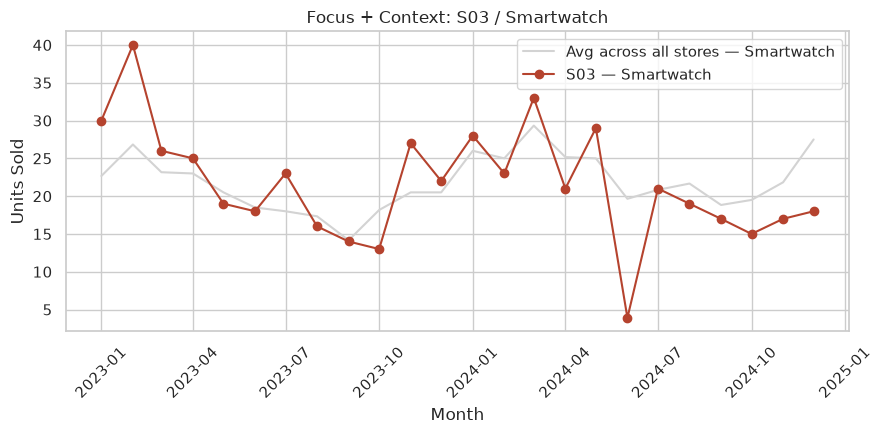

In [8]:

# --- Part B: drill-down with context preserved ---
# TODO 1: build an overview plotly line chart of units_sold over month, one line per (store_id, product)
#         combination, with hover showing store_id + product (cheap-tier epistemic action)
sales_df["pair_label"] = sales_df["store_id"] + " / " + sales_df["product"]

fig_overview = px.line(
    sales_df,
    x="month",
    y="units_sold",
    color="pair_label",
    hover_data=["store_id", "product"],
    title="Units Sold Over Time — All (store, product) Pairs",
)
fig_overview.update_layout(showlegend=False)
fig_overview.show()

# TODO 2: using the (store_id, product) pair you identified as the top anomaly in Part A,
#         plot its monthly units_sold trend (focus) together with the average trend for that SAME
#         product across all other stores (context), on one shared chart
top_store, top_product = anomaly_ranking.index[0]

focus = sales_df[(sales_df.store_id == top_store) & (sales_df["product"] == top_product)].groupby("month").units_sold.mean()
context = sales_df[sales_df["product"] == top_product].groupby("month").units_sold.mean()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(context.index, context.values, color="lightgray", label=f"Avg across all stores — {top_product}")
ax.plot(focus.index, focus.values, color="#b5432e", marker="o", label=f"{top_store} — {top_product}")
ax.set_xlabel("Month")
ax.set_ylabel("Units Sold")
ax.set_title(f"Focus + Context: {top_store} / {top_product}")
ax.legend()
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()



**Reflection:** Which interaction-cost tier (eye fixation / hover / click-to-open panel / window
replacement) did you use to first *spot* the anomaly, and which did you use to *investigate* it? Was
using two different tiers the right call, per the lecture's design rule?

_Your answer:_

I first spotted the anomaly at the **hover** tier — scanning the overview Plotly line chart and hovering over the line with the visible dip to confirm its `store_id`/`product` (S03 / Smartwatch). I then investigated it at the **click-to-open-panel** tier — the separate focus+context matplotlib chart that plots that one store/product against the average trend for the same product. Using two different tiers was the right call: the lecture's rule is to use the cheapest tier that answers the question, and hovering was enough to identify the anomaly, but confirming *how* severe the dip was against a fair comparison needed a dedicated, more detailed panel rather than replacing the whole overview.



## Task 5 — Table Lens: A Scannable Product Performance Table

**Real-world usage:** A manager wants a single table listing every product's total revenue, total
profit, and average rating across all stores — but a plain spreadsheet of 10 rows x many numeric
columns is still hard to compare at a glance across all three metrics simultaneously.

**Why this technique:** Table Lens (Slide 27) maps numeric columns to in-cell bars, so magnitude
differences are visible pre-attentively while the table stays sortable/readable as text.

### Your task
1. Build a summary DataFrame: one row per `product`, columns for total `revenue`, total `profit`, and
   mean `avg_rating`.
2. Sort it by total revenue, descending.
3. Style it as a Table Lens using `.style.bar(...)` — a different bar color per numeric column, as in
   the Demo notebook — and add a meaningful `.set_caption(...)`.
4. Below the table, add **one more cell**: sort the *same* summary table by `profit` instead of
   `revenue`, and re-render the styled table. Do the top rows change order? Note what that tells a
   manager about revenue vs. profitability.


In [9]:

# TODO: build product_summary with columns: product, revenue (sum), profit (sum), avg_rating (mean)
product_summary = sales_df.groupby("product", as_index=False).agg(
    revenue=("revenue", "sum"),
    profit=("profit", "sum"),
    avg_rating=("avg_rating", "mean"),
)

# TODO: sort descending by revenue
product_summary = product_summary.sort_values("revenue", ascending=False)

# TODO: style with .style.bar(...) per numeric column + .set_caption(...)
(product_summary.style
    .bar(subset=["revenue"], color="#3b6ea5")
    .bar(subset=["profit"], color="#5fa55a")
    .bar(subset=["avg_rating"], color="#b5432e")
    .set_caption("Product Performance — Table Lens (sorted by revenue)"))


,product,revenue,profit,avg_rating
5,Smartwatch,15706358.100000,3881507.114978,4.088194
0,Air Fryer,10901274.000000,2593731.370256,4.036111
4,Running Shoes,9688731.000000,2303074.979248,4.100000
2,Dumbbell Set,7796880.000000,1829126.919623,4.113889
1,Blender,7648773.000000,1860308.558382,4.039583
6,Track Jacket,6992502.000000,1610283.087008,4.131250
7,USB-C Hub,3842442.000000,907435.115420,4.087500
8,Wireless Earbuds,3769985.000000,890553.519307,4.086806
3,Laptop Sleeve,2801284.000000,664357.720743,4.076389
9,Yoga Mat,1560447.000000,370892.396491,4.068750


In [10]:

# TODO: re-sort product_summary by profit descending and re-render the styled table
product_summary_by_profit = product_summary.sort_values("profit", ascending=False)

(product_summary_by_profit.style
    .bar(subset=["revenue"], color="#3b6ea5")
    .bar(subset=["profit"], color="#5fa55a")
    .bar(subset=["avg_rating"], color="#b5432e")
    .set_caption("Product Performance — Table Lens (sorted by profit)"))


,product,revenue,profit,avg_rating
5,Smartwatch,15706358.100000,3881507.114978,4.088194
0,Air Fryer,10901274.000000,2593731.370256,4.036111
4,Running Shoes,9688731.000000,2303074.979248,4.100000
1,Blender,7648773.000000,1860308.558382,4.039583
2,Dumbbell Set,7796880.000000,1829126.919623,4.113889
6,Track Jacket,6992502.000000,1610283.087008,4.131250
7,USB-C Hub,3842442.000000,907435.115420,4.087500
8,Wireless Earbuds,3769985.000000,890553.519307,4.086806
3,Laptop Sleeve,2801284.000000,664357.720743,4.076389
9,Yoga Mat,1560447.000000,370892.396491,4.068750



**Your observation (revenue-sorted vs profit-sorted top rows):**

_Type here._

The very top of the table barely moves — Smartwatch, Air Fryer and Running Shoes stay 1st-2nd-3rd either way — but Blender and Dumbbell Set swap places right below them: Blender has slightly lower revenue than Dumbbell Set but a higher profit margin, so it edges ahead once sorted by profit. This tells a manager that revenue rank isn't a safe proxy for profitability — a product that looks like a bigger seller can still generate less actual profit than a product just behind it in revenue but with a fatter margin.



## Task 6 — Assemble a Single-Screen Monitoring Dashboard (open-ended)

**Real-world usage:** All three complaints at once. UrbanCart wants a **single screen** a regional
manager can glance at every morning — no interaction required to read the headline state, per the
Dashboard Patterns slide (Slide 28): critical indicators visible at a glance, with a peripheral-tier
alert that uses color (not subtlety) to flag something that needs attention.

### Your task
Build a 2x2 dashboard (`plt.subplots(2, 2, ...)`) with:

1. **Top-left — KPI summary panel** (`ax.axis("off")` + `ax.text(...)`): total revenue, total profit,
   overall average rating, and number of active stores, computed from `sales_df`.
2. **Top-right — mid-term analysis panel**: revenue by `region` (bar chart).
3. **Bottom-left — long-term trend panel**: total revenue by `month`, across all stores (line chart).
4. **Bottom-right — peripheral alert panel**: check whether **any** `(store_id, product)` pair has a
   month where `units_sold` fell below **25% of its own median** for that pair (this is the anomaly
   you found in Task 4, but write the check generically so it would catch *any* such case, not just
   the one you already know about). Show a red "ALERT — N issue(s) found" indicator if any exist, or
   a green "OK" indicator if not.

This task is intentionally the least scaffolded — you decide the exact `groupby` calls, panel layout
details, and styling. Reuse patterns from Tasks 1-5 and the Demo notebook where they fit, but write
the logic yourself.


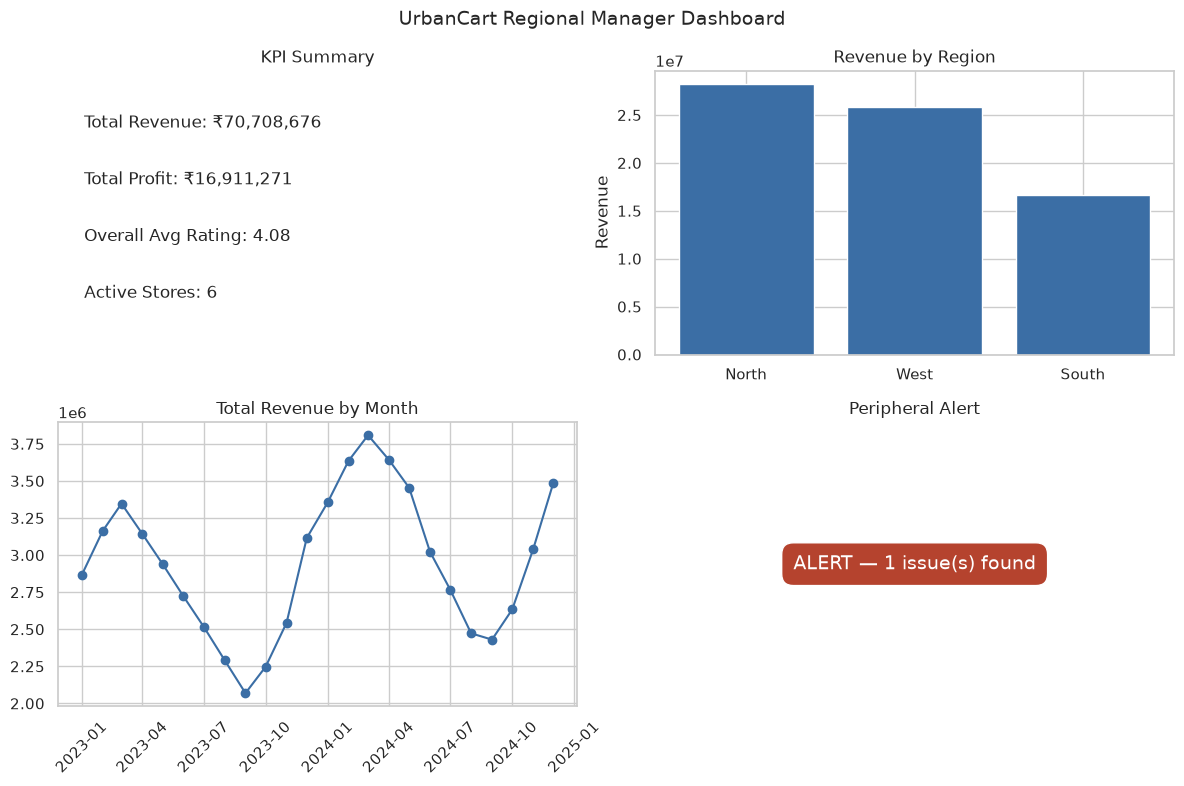

In [11]:

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# --- Panel 1: KPI summary (top-left) ---
total_revenue = sales_df.revenue.sum()
total_profit = sales_df.profit.sum()
overall_rating = sales_df.avg_rating.mean()
n_stores = sales_df.store_id.nunique()

axes[0, 0].axis("off")
axes[0, 0].text(0.05, 0.8, f"Total Revenue: ₹{total_revenue:,.0f}", fontsize=12, transform=axes[0, 0].transAxes)
axes[0, 0].text(0.05, 0.6, f"Total Profit: ₹{total_profit:,.0f}", fontsize=12, transform=axes[0, 0].transAxes)
axes[0, 0].text(0.05, 0.4, f"Overall Avg Rating: {overall_rating:.2f}", fontsize=12, transform=axes[0, 0].transAxes)
axes[0, 0].text(0.05, 0.2, f"Active Stores: {n_stores}", fontsize=12, transform=axes[0, 0].transAxes)
axes[0, 0].set_title("KPI Summary")

# --- Panel 2: revenue by region (top-right) ---
region_revenue = sales_df.groupby("region").revenue.sum().sort_values(ascending=False)
axes[0, 1].bar(region_revenue.index, region_revenue.values, color="#3b6ea5")
axes[0, 1].set_title("Revenue by Region")
axes[0, 1].set_ylabel("Revenue")

# --- Panel 3: total revenue by month, all stores (bottom-left) ---
monthly_revenue = sales_df.groupby("month").revenue.sum()
axes[1, 0].plot(monthly_revenue.index, monthly_revenue.values, marker="o", color="#3b6ea5")
axes[1, 0].set_title("Total Revenue by Month")
axes[1, 0].tick_params(axis="x", rotation=45)

# --- Panel 4: peripheral alert panel (bottom-right) ---
# TODO: generically detect any (store_id, product) pair with a month below 25% of its own median
#       units_sold, then render a red "ALERT -- N issue(s) found" or green "OK" indicator
pair_median = sales_df.groupby(["store_id", "product"]).units_sold.median().rename("pair_median")
merged = sales_df.merge(pair_median, on=["store_id", "product"])
issues = merged[merged.units_sold < 0.25 * merged["pair_median"]]
n_issues = issues[["store_id", "product", "month"]].drop_duplicates().shape[0]

axes[1, 1].axis("off")
if n_issues > 0:
    axes[1, 1].text(0.5, 0.5, f"ALERT — {n_issues} issue(s) found", fontsize=14, color="white",
                     ha="center", va="center", bbox=dict(facecolor="#b5432e", boxstyle="round,pad=0.6"))
else:
    axes[1, 1].text(0.5, 0.5, "OK", fontsize=14, color="white",
                     ha="center", va="center", bbox=dict(facecolor="#5fa55a", boxstyle="round,pad=0.6"))
axes[1, 1].set_title("Peripheral Alert")

fig.suptitle("UrbanCart Regional Manager Dashboard", fontsize=14)
plt.tight_layout()
plt.show()



## Reflection

Answer briefly, referring back to the three manager complaints from the scenario intro:

1. Which single technique from this activity do you think gives UrbanCart's managers the *biggest*
   time saving, and why?
2. Which technique was hardest to implement well, and what design trade-off (from the lecture) did you
   have to think about while building it?
3. If you had to add **one more** interaction technique from the lecture that this activity didn't
   cover (e.g. geometric fisheye, magic lens, network zooming, model-based planning), where in this
   retail scenario would it actually be useful, and why?

_Your answers here._

1. Coordinated views + brushing (Task 3) gives the biggest time saving — it directly kills complaint #2 by letting a manager pick one store from a single dropdown and see its category mix and trend instantly, instead of flipping between separate PDF pages for every store.
2. The focus+context drill-down (Task 4) was hardest to get right: the trade-off was between showing enough detail to make the dip obvious and keeping the "all stores" context visible so the manager can judge how unusual the dip really is, without the context line clutter drowning out the focus line.
3. I'd add a **geometric fisheye** view over the store/product overview line chart in Task 4 — with hundreds of products across 500 stores, a fisheye would let a manager keep every line's rough position on screen (context) while magnifying the region around whichever line they're currently inspecting (focus), which scales much better than plain hover once the overview chart gets crowded.
